In [1]:
import os
import cv2
import numpy as np
import random
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from deap import base, creator, tools, algorithms


In [2]:
IMG_SIZE = 512
INPUT_DIR = "dataset"
PROCESSED_DIR = "processed_dataset"

LABELS = {
    "Normal": 0,
    "Bengin": 1,
    "Malignant": 2
}

os.makedirs(PROCESSED_DIR, exist_ok=True)
print("✅ Configuration loaded")


✅ Configuration loaded


In [3]:
print("\n🔹 STEP 1: IMAGE PREPROCESSING")

def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.GaussianBlur(img, (5, 5), 0)
    img = cv2.medianBlur(img, 5)

    clahe = cv2.createCLAHE(2.0, (8, 8))
    img = clahe.apply(img)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

for label in os.listdir(INPUT_DIR):
    in_dir = os.path.join(INPUT_DIR, label)
    out_dir = os.path.join(PROCESSED_DIR, label)
    os.makedirs(out_dir, exist_ok=True)

    print(f"📁 Processing {label} images")

    for img_name in os.listdir(in_dir):
        img_path = os.path.join(in_dir, img_name)
        processed = preprocess_image(img_path)
        cv2.imwrite(
            os.path.join(out_dir, img_name),
            (processed * 255).astype(np.uint8)
        )

print("✅ Image preprocessing completed")



🔹 STEP 1: IMAGE PREPROCESSING
📁 Processing Bengin images
📁 Processing Malignant images
📁 Processing Normal images
✅ Image preprocessing completed



🖼 Showing preprocessing difference
Left  → Original Image
Right → Preprocessed Image (Noise removed + Contrast enhanced)


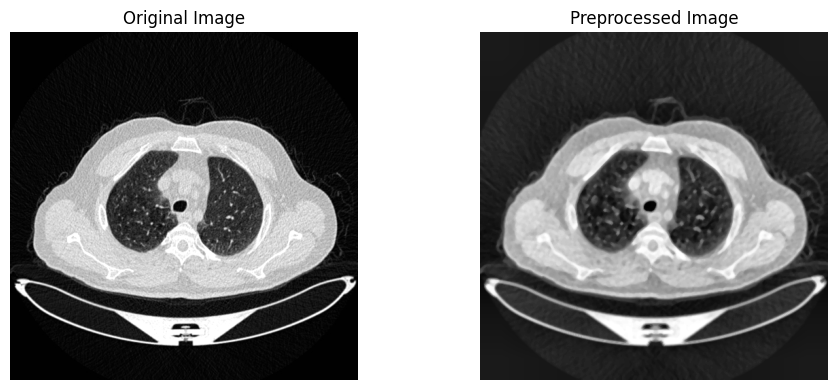

In [16]:
import matplotlib.pyplot as plt

def show_preprocessing_difference(img_path):
    # Original image
    original = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # Preprocessed image
    processed = preprocess_image(img_path)

    print("\n🖼 Showing preprocessing difference")
    print("Left  → Original Image")
    print("Right → Preprocessed Image (Noise removed + Contrast enhanced)")

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(processed, cmap="gray")
    plt.title("Preprocessed Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
sample_image = os.path.join(INPUT_DIR, "Normal", os.listdir(os.path.join(INPUT_DIR, "Normal"))[0])

show_preprocessing_difference(sample_image)


In [4]:
print("\n🔹 STEP 2: LOADING DENSENET FEATURE EXTRACTOR")

base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = GlobalAveragePooling2D()(base_model.output)
cnn_model = Model(base_model.input, x)

print("✅ DenseNet loaded (1024 deep features)")



🔹 STEP 2: LOADING DENSENET FEATURE EXTRACTOR
✅ DenseNet loaded (1024 deep features)


In [5]:
def extract_densenet_features(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)
    return cnn_model.predict(img, verbose=0).flatten()


In [6]:
print("\n🔹 STEP 3: LBP FEATURE EXTRACTION")

def extract_lbp_features(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    lbp = local_binary_pattern(img, P=8, R=1, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 59), density=True)
    return hist

print("✅ LBP features ready (58 features)")



🔹 STEP 3: LBP FEATURE EXTRACTION
✅ LBP features ready (58 features)


In [7]:
print("\n🔹 STEP 4: GLCM FEATURE EXTRACTION")

def extract_glcm_features(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    glcm = graycomatrix(img, [1], [0], 256, symmetric=True, normed=True)

    return np.array([
        graycoprops(glcm, 'contrast')[0, 0],
        graycoprops(glcm, 'correlation')[0, 0],
        graycoprops(glcm, 'energy')[0, 0],
        graycoprops(glcm, 'homogeneity')[0, 0]
    ])

print("✅ GLCM features ready (4 features)")



🔹 STEP 4: GLCM FEATURE EXTRACTION
✅ GLCM features ready (4 features)


In [8]:
print("\n🔹 STEP 5: HYBRID FEATURE FUSION")

def extract_hybrid_features(img_path):
    return np.concatenate([
        extract_densenet_features(img_path),
        extract_lbp_features(img_path),
        extract_glcm_features(img_path)
    ])



🔹 STEP 5: HYBRID FEATURE FUSION


In [9]:
print("\n🔹 STEP 6: DATASET CREATION")

X, y = [], []

for label_name, label_id in LABELS.items():
    folder = os.path.join(PROCESSED_DIR, label_name)
    print(f"📂 Loading {label_name}")

    for img in os.listdir(folder):
        path = os.path.join(folder, img)
        X.append(extract_hybrid_features(path))
        y.append(label_id)

X = np.array(X)
y = np.array(y)

print("✅ Dataset created")
print("X shape:", X.shape)
print("y shape:", y.shape)



🔹 STEP 6: DATASET CREATION
📂 Loading Normal
📂 Loading Bengin
📂 Loading Malignant
✅ Dataset created
X shape: (1097, 1086)
y shape: (1097,)


In [18]:
print(X)
print(y)

[[-0.27993994  1.15495684  0.35956076 ...  0.20998888 -0.12243493
  -0.29172382]
 [-0.14059272  0.27290275 -0.24773183 ... -0.85442831 -0.06204735
  -0.25147628]
 [ 1.18703601  2.48245318 -0.14230793 ... -1.31960806 -0.11213887
  -0.30216823]
 ...
 [ 0.32593171  0.6169167   0.95341692 ...  0.04920743  1.79324044
   1.42876389]
 [ 0.03245479  1.31826315  1.0426581  ...  0.10132363  1.79131404
   1.43215947]
 [ 0.31563888  0.16752551  0.53176107 ...  0.22232617  1.79602455
   1.4402352 ]]
[0 0 0 ... 2 2 2]


In [10]:
print("\n🔹 STEP 7: FEATURE SCALING")

scaler = StandardScaler()
X = scaler.fit_transform(X)

joblib.dump(scaler, "feature_scaler.pkl")
print("✅ Features scaled & scaler saved")



🔹 STEP 7: FEATURE SCALING
✅ Features scaled & scaler saved


In [11]:
print("\n🧬 STEP 8: GENETIC ALGORITHM FEATURE SELECTION")

NUM_FEATURES = X.shape[1]

if "FitnessMax" not in creator.__dict__:
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if "Individual" not in creator.__dict__:
    creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual,
                 toolbox.attr_bool, NUM_FEATURES)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluate(individual):
    idx = [i for i, bit in enumerate(individual) if bit]
    if len(idx) == 0:
        return 0,
    acc = cross_val_score(
        RandomForestClassifier(100, random_state=42),
        X[:, idx], y, cv=5
    ).mean()
    return acc - 0.1 * (len(idx) / NUM_FEATURES),

toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.02)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(30)
algorithms.eaSimple(pop, toolbox, 0.5, 0.2, 25, verbose=True)

best = tools.selBest(pop, 1)[0]
selected_features = [i for i, b in enumerate(best) if b]

np.save("selected_features.npy", selected_features)

print("✅ GA completed")
print("Selected features:", len(selected_features))



🧬 STEP 8: GENETIC ALGORITHM FEATURE SELECTION
gen	nevals
0  	30    
1  	19    
2  	19    
3  	16    
4  	20    
5  	17    
6  	19    
7  	26    
8  	19    
9  	14    
10 	25    
11 	15    
12 	19    
13 	17    
14 	23    
15 	15    
16 	21    
17 	20    
18 	12    
19 	22    
20 	13    
21 	15    
22 	16    
23 	16    
24 	17    
25 	21    
✅ GA completed
Selected features: 540


In [12]:
print("\n🔹 STEP 9: SVM TRAINING (3-CLASS)")

X_sel = X[:, selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.2, stratify=y, random_state=42
)

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)
print("✅ SVM training completed")



🔹 STEP 9: SVM TRAINING (3-CLASS)
✅ SVM training completed



SVM Accuracy: 0.9863636363636363

Confusion Matrix:
 [[ 83   0   0]
 [  3  21   0]
 [  0   0 113]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98        83
      Benign       1.00      0.88      0.93        24
   Malignant       1.00      1.00      1.00       113

    accuracy                           0.99       220
   macro avg       0.99      0.96      0.97       220
weighted avg       0.99      0.99      0.99       220



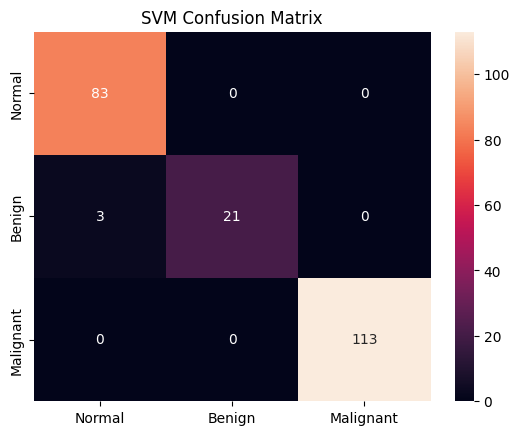

In [13]:
y_pred = svm.predict(X_test)

print("\nSVM Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["Normal", "Benign", "Malignant"]
))

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Normal","Benign","Malignant"],
            yticklabels=["Normal","Benign","Malignant"])
plt.title("SVM Confusion Matrix")
plt.show()


In [14]:
joblib.dump(svm, "lung_cancer_svm_3class.pkl")
print("✅ SVM model saved")


✅ SVM model saved


In [30]:
print("\n🔹 STEP 10: SINGLE IMAGE PREDICTION")

svm = joblib.load("lung_cancer_svm_3class.pkl")
scaler = joblib.load("feature_scaler.pkl")
selected_features = np.load("selected_features.npy")

CLASS_NAMES = ["Normal", "Benign", "Malignant"]

def predict_single_image_svm(img_path):
    feat = extract_hybrid_features(img_path).reshape(1, -1)
    feat = scaler.transform(feat)
    feat = feat[:, selected_features]

    probs = svm.predict_proba(feat)[0]
    cls = np.argmax(probs)

    return CLASS_NAMES[cls], probs[cls]

label, conf = predict_single_image_svm(
    "dataset/Normal/Normal case (4).jpg"
)

print("🩺 Prediction:", label)
print("🔐 Confidence:", round(conf * 100, 2), "%")



🔹 STEP 10: SINGLE IMAGE PREDICTION
🩺 Prediction: Normal
🔐 Confidence: 44.83 %
